Bu projede, IMDB veri setinde yer alan 50.000 film yorumu kullanılarak derin öğrenme tabanlı bir duygu analizi modeli geliştirilmiştir. Projenin amacı, kullanıcılar tarafından yazılan film yorumlarının pozitif veya negatif olarak sınıflandırılmasıdır. Veri ön işleme aşamasında yorum metinleri Tokenizer yardımıyla sayısal verilere dönüştürülmüş, ardından tüm yorumlar aynı uzunluğa getirilmek amacıyla Padding işlemi uygulanmıştır. Model mimarisinde Embedding katmanı ile kelime temsilleri oluşturulmuş, LSTM katmanı ile metin içerisindeki bağlamsal ilişkiler öğrenilmiş ve son katmanda sigmoid aktivasyon fonksiyonu kullanılarak ikili sınıflandırma gerçekleştirilmiştir. Proje boyunca Python, TensorFlow, Keras, Pandas ve Scikit-Learn kütüphanelerinden yararlanılmıştır.

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('IMDB_Dataset.csv')

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
# Hedef değişkeni sayısala çeviriyoruz.
df["sentiment"] = df["sentiment"].replace({"negative":0, "positive":1})
df.head()

C:\Users\mehmet.sefer.kaya\AppData\Local\Temp\ipykernel_14540\1954676597.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sentiment"] = df["sentiment"].replace({"negative":0, "positive":1})


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [8]:
df['sentiment'].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

In [10]:
# Yorum uzunluklarına bakıyoruz
df["review_length"] = df["review"].apply(len)

df["review_length"].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

In [11]:
df.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,1,1761
1,A wonderful little production. <br /><br />The...,1,998
2,I thought this was a wonderful way to spend ti...,1,926
3,Basically there's a family where a little boy ...,0,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317


In [13]:
x = df["review"]
y = df["sentiment"]

In [14]:
# Train-Test ayırıyoruz.

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [15]:
print(x_train.shape)
print(x_test.shape)

(40000,)
(10000,)


In [16]:
# Tokenizer oluşturuyoruz.
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(x_train)

In [17]:
# Yorumları sayıya çeviriyoruz.
x_egitim_dizi = tokenizer.texts_to_sequences(x_train)

x_test_dizi = tokenizer.texts_to_sequences(x_test)

In [19]:
# Dizileri aynı uzunluğa getiriyoruz.Padding uyguluyoruz.
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 200

x_train_pad = pad_sequences(x_egitim_dizi, maxlen=maxlen)

x_test_pad = pad_sequences(x_test_dizi, maxlen=maxlen)

print(x_train_pad.shape)
print(x_test_pad.shape)

(40000, 200)
(10000, 200)


In [20]:
# LSTM modelimizi oluşturuyoruz.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()

model.add(Embedding(input_dim=max_words, output_dim=128, input_length=maxlen))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

C:\Users\mehmet.sefer.kaya\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(x_train_pad, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.8260 - loss: 0.3928 - val_accuracy: 0.8741 - val_loss: 0.3046
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9046 - loss: 0.2472 - val_accuracy: 0.8771 - val_loss: 0.2935
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.9330 - loss: 0.1839 - val_accuracy: 0.8854 - val_loss: 0.3114
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.9503 - loss: 0.1375 - val_accuracy: 0.8760 - val_loss: 0.3486
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.9541 - loss: 0.1278 - val_accuracy: 0.8709 - val_loss: 0.4075


In [22]:
history.history["accuracy"]
history.history["val_accuracy"]

[0.8741250038146973,
 0.8771250247955322,
 0.8853750228881836,
 0.8759999871253967,
 0.8708750009536743]

In [23]:
#Modeli test verisiyle değerlendiriyoruz.
test_loss, test_accuracy = model.evaluate(x_test_pad, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8725 - loss: 0.3897
Test Loss: 0.3897230923175812
Test Accuracy: 0.8725000023841858


In [24]:
# Tahminleri alıyoruz ve 0-1 sınıfına çeviriyoruz.
import numpy as np

tahminler = model.predict(x_test_pad)

tahmin_siniflari = (tahminler > 0.5).astype("int32")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [26]:
# Classification report ve confusion matrix oluşturuyoruz.

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, tahmin_siniflari))

print(classification_report(y_test, tahmin_siniflari))

[[4553  408]
 [ 867 4172]]
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      4961
           1       0.91      0.83      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



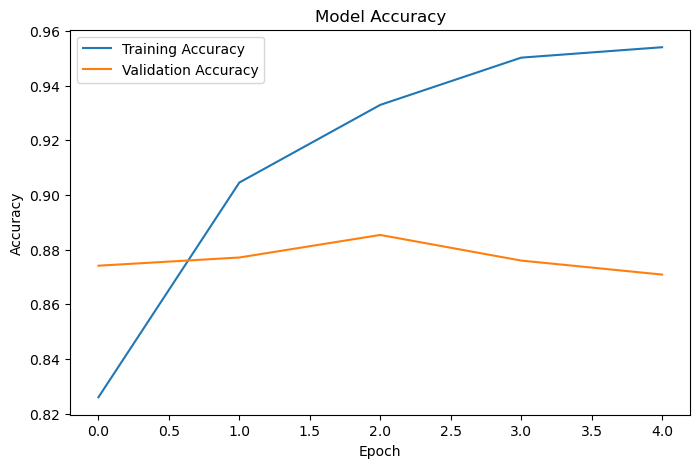

In [27]:
# Eğitim ve doğrulama accuracy değerlerini çiziyoruz.
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

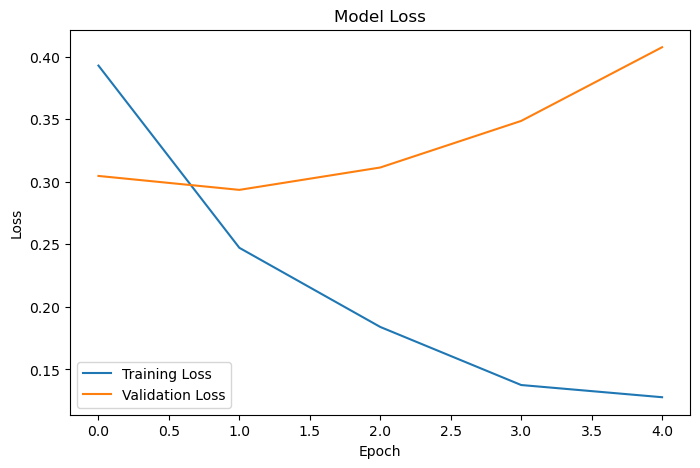

In [28]:
# Eğitim ve doğrulama loss değerlerini çiziyoruz.
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

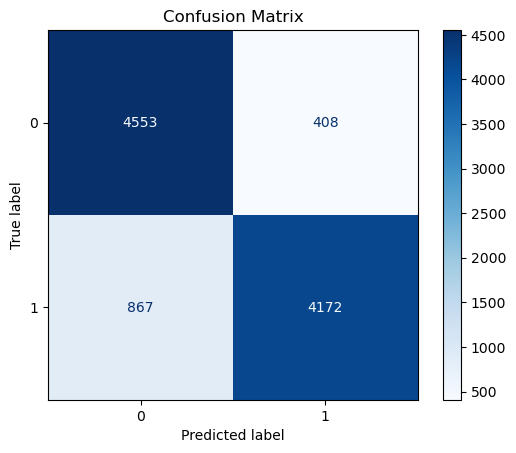

In [30]:
#Confusion Matrix'i görselleştiriyoruz.
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tahmin_siniflari,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [31]:
# Modeli kaydediyoruz.
model.save("imdb_lstm_model.h5")

In [32]:
#Tokenizer'ı kaydediyoruz.
import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

Geliştirilen LSTM tabanlı duygu analizi modeli test verisi üzerinde yaklaşık %87,25 doğruluk oranı elde etmiştir. Ayrıca sınıflandırma raporunda precision, recall ve F1-score değerlerinin dengeli olduğu görülmüş ve modelin hem pozitif hem de negatif yorumları başarılı şekilde sınıflandırabildiği tespit edilmiştir. Confusion Matrix sonuçları incelendiğinde modelin yanlış sınıflandırma oranının düşük olduğu ve genel performansının tatmin edici seviyede bulunduğu görülmektedir. Elde edilen sonuçlar, LSTM mimarisinin metin sınıflandırma problemlerinde etkili bir yöntem olduğunu göstermektedir. Proje kapsamında oluşturulan model, kullanıcı tarafından girilen yeni film yorumlarının duygu durumunu tahmin edebilecek şekilde kullanılabilir hale getirilmiştir.